In [1]:
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import time, copy


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [3]:
zip_path = "/content/drive/MyDrive/archive_5.zip"
extract_path = "/content"


In [4]:
import zipfile, os

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

print("Extraction complete!")


Extraction complete!


In [5]:
import os

for root, dirs, files in os.walk("/content/DataSet", topdown=True):
    print("ROOT:", root)
    print("DIRS:", dirs[:10])
    print("FILES:", files[:10])
    print("------")
    break


ROOT: /content/DataSet
DIRS: ['Train_Dataset', 'Valid_Dataset', 'Test_Dataset']
FILES: []
------


In [14]:
DATA_DIR = "/content/DataSet"

TRAIN_DIR = os.path.join(DATA_DIR, "Train_Dataset")
VALID_DIR = os.path.join(DATA_DIR, "Valid_Dataset")
TEST_DIR  = os.path.join(DATA_DIR, "Test_Dataset")

BATCH_SIZE = 32
LEARNING_RATE = 0.0001
NUM_EPOCHS = 1


In [7]:
train_df = pd.read_csv(os.path.join(TRAIN_DIR, "labels.csv"), header=None)
valid_df = pd.read_csv(os.path.join(VALID_DIR, "labels.csv"), header=None)
test_df  = pd.read_csv(os.path.join(TEST_DIR, "labels.csv"), header=None)

all_df = pd.concat([train_df, valid_df, test_df])

label_encoder = LabelEncoder()
label_encoder.fit(all_df[3])   # class_name column

NUM_CLASSES = len(label_encoder.classes_)

print("Classes found:", label_encoder.classes_)
print("NUM_CLASSES =", NUM_CLASSES)


Classes found: ['adapter_plate_triangular' 'bracket_big' 'clamp_small'
 'engine_part_cooler_round' 'engine_part_cooler_square' 'injection_pump'
 'screw' 'star' 'tee_connector' 'thread']
NUM_CLASSES = 10


In [8]:
class IndustrialPartsDataset(Dataset):
    def __init__(self, root_dir, label_encoder, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        df = pd.read_csv(os.path.join(root_dir, "labels.csv"),
                         header=None,
                         names=['Index','ImageName','ClassID','ClassName'])

        df['label_idx'] = label_encoder.transform(df['ClassName'])
        self.df = df

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = row['ImageName']
        label = row['label_idx']

        img_path = os.path.join(self.root_dir, "images", img_name)

        try:
            image = Image.open(img_path).convert("RGB")
        except:
            image = Image.new("RGB", (224,224))

        if self.transform:
            image = self.transform(image)

        return image, label


In [9]:
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224,224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],
                             [0.229,0.224,0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],
                             [0.229,0.224,0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],
                             [0.229,0.224,0.225])
    ])
}


In [10]:
train_dataset = IndustrialPartsDataset(TRAIN_DIR, label_encoder, data_transforms['train'])
val_dataset   = IndustrialPartsDataset(VALID_DIR,  label_encoder, data_transforms['val'])
test_dataset  = IndustrialPartsDataset(TEST_DIR,   label_encoder, data_transforms['test'])

dataloaders = {
    'train': DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True),
    'val':   DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False),
    'test':  DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False),
}

dataset_sizes = {
    'train': len(train_dataset),
    'val':   len(val_dataset),
    'test':  len(test_dataset),
}

print("Dataset sizes:", dataset_sizes)


Dataset sizes: {'train': 70000, 'val': 10000, 'test': 20000}


In [11]:
def initialize_model(num_classes):
    model = models.resnet50(weights="IMAGENET1K_V1")
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)
    return model

model = initialize_model(NUM_CLASSES).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 193MB/s]


In [12]:
def train_model(model, criterion, optimizer, num_epochs=10):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        print("-"*20)

        for phase in ['train','val']:
            model.train() if phase=='train' else model.eval()

            running_loss = 0.0
            running_corrects = 0

            for x,y in dataloaders[phase]:
                x,y = x.to(device), y.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase=='train'):
                    outputs = model(x)
                    loss = criterion(outputs,y)
                    _, preds = torch.max(outputs,1)

                    if phase=='train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * x.size(0)
                running_corrects += torch.sum(preds==y)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc  = running_corrects.double() / dataset_sizes[phase]

            print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            if phase=='val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    print("Best Val Acc:", best_acc.item())
    model.load_state_dict(best_model_wts)
    return model


In [15]:
model = train_model(model, criterion, optimizer, NUM_EPOCHS)


Epoch 1/1
--------------------
train Loss: 0.0587 Acc: 0.9827
val Loss: 0.0856 Acc: 0.9716

Best Val Acc: 0.9716


In [16]:
torch.save(model.state_dict(), "resnet50_industrial_trained.pth")
print("Model saved!")


Model saved!


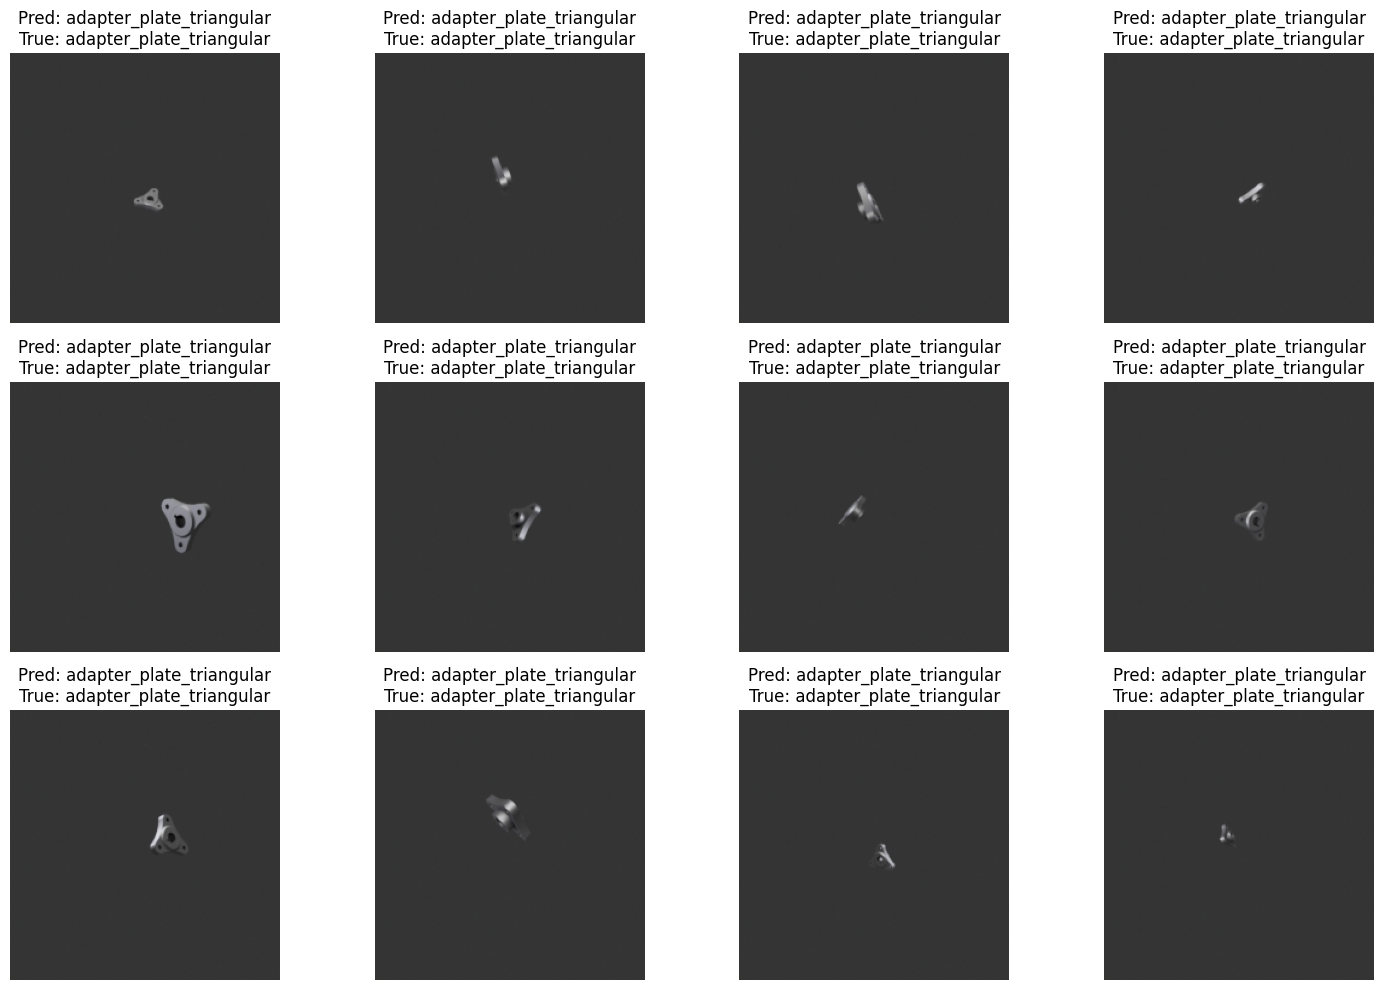

In [17]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    inp  = std * inp + mean
    inp  = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title:
        plt.title(title)
    plt.axis("off")

# Get one batch of test data
inputs, labels = next(iter(dataloaders['test']))
inputs = inputs.to(device)
labels = labels.to(device)

# Run inference
model.eval()
with torch.no_grad():
    outputs = model(inputs)
    _, preds = torch.max(outputs, 1)

# Display predictions
plt.figure(figsize=(15, 10))
for i in range(min(len(inputs), 12)):  # show 12 images
    ax = plt.subplot(3, 4, i+1)
    imshow(inputs[i].cpu(),
           title=f"Pred: {label_encoder.inverse_transform([preds[i].item()])[0]}\n"
                 f"True: {label_encoder.inverse_transform([labels[i].item()])[0]}")
plt.tight_layout()
plt.show()
